In [1]:
# for checking file locations
import os
import glob
import os.path
# use warnings
import warnings
# use regex
import re
# for pandas
import pandas as pd
# for numpy operations on pandas columns
import numpy as np
# for making the scatterplot
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:

def get_variant_feature_distances(qtl_output, feature_start_column='feature_start', feature_end_column='feature_end', variant_pos_column='snp_position'):
    """
    Calculate the distances of variants from feature start and end positions.

    This function computes the distances of variants from the start and end positions of features in a given dataframe.
    It identifies whether the variants are inside the features and calculates the absolute distances for those outside.

    Parameters:
    qtl_output (pd.DataFrame): DataFrame containing the variant and feature positions.
    feature_start_column (str): Column name for feature start positions. Default is 'feature_start'.
    feature_end_column (str): Column name for feature end positions. Default is 'feature_end'.
    variant_pos_column (str): Column name for variant positions. Default is 'snp_position'.

    Returns:
    pd.Series: A series containing the absolute distances of variants from the nearest feature boundary, 
               with distances set to zero for variants inside the features.
    """

    # the way this works is like this. Given a dataframe like this
    #   snp_position  feature_start  feature_end
    #0             5             10           15
    #1             5              2            7
    #2            10              3            7
    #3             5              7            2
    #
    # we want to calculate the distances first
    #   dist_start  dist_end
    #0           5        10
    #1          -3         2
    #2          -7        -3
    #3           2        -3
    #
    # some of the variants will be inside the start and stop. We can look at the signs of the start and stop
    #       dist_start  dist_end  dist_start_sign  dist_end_sign
    #0           5        10                1              1
    #1          -3         2               -1              1
    #2          -7        -3               -1             -1
    #3           2        -3                1             -1
    #
    # we can then multiply the signs, if both are negative or both are positive, you will end up with a positive number.
    # Only if the start distance is positive and the stop negative, or vice versa, is the variant inside the feature
    #   dist_start  dist_end  dist_start_sign  dist_end_sign  multiplied_sign
    #0           5        10                1              1                1
    #1          -3         2               -1              1               -1
    #2          -7        -3               -1             -1                1
    #3           2        -3                1             -1               -1
    #
    # now we have identified the ones that are inside, we just have to get the distances for those that are outside. We care about how close the variant is, not about on which flank it is.
    # Depending on the flank however the number might be positive or negative. We can solve that by making the distance an absolute number
    #       dist_start  dist_end  dist_start_sign  dist_end_sign  multiplied_sign  \
    #0           5        10                1              1                1   
    #1          -3         2               -1              1               -1   
    #2          -7        -3               -1             -1                1   
    #3           2        -3                1             -1               -1   
    #
    #   dist_start_abs  dist_end_abs  
    #0               5            10  
    #1               3             2  
    #2               7             3  
    #3               2             3  
    #
    # now we just have to take the minimum of the absolute distances, but set it to zero when the variant is inside the feature
    #       dist_start  dist_end  dist_start_sign  dist_end_sign  multiplied_sign  \
    #0           5        10                1              1                1   
    #1          -3         2               -1              1               -1   
    #2          -7        -3               -1             -1                1   
    #3           2        -3                1             -1               -1   
    #
    #   dist_start_abs  dist_end_abs  absolute_distance  absolute_distance_inside  
    #0               5            10                  5                         5  
    #1               3             2                  2                         0  
    #2               7             3                  3                         3  
    #3               2             3                  2                         0  
    
    # get the distance from the start
    dist_start = qtl_output[feature_start_column] - qtl_output[variant_pos_column]
    # and the distance from the end
    dist_end = qtl_output[feature_end_column] - qtl_output[variant_pos_column]
    # get the signs
    dist_start_sign = dist_start.apply(np.sign)
    dist_end_sign = dist_end.apply(np.sign)
    # get the multiplied sign
    multiplied_sign = dist_start_sign * dist_end_sign
    # get the absolute distances
    dist_start_abs = dist_start.apply(np.abs)
    dist_end_abs = dist_end.apply(np.abs)
    # get the minimal value, so either the start or end distance, depending on which is smaller
    absolute_distance = np.minimum(dist_start_abs, dist_end_abs)
    # but make that zero if the multiplied sign was smaller than zero
    absolute_distance[multiplied_sign < 0] = 0
    #print(pd.DataFrame({'dist_start' : dist_start, 'dist_end': dist_end, 'dist_start_sign' : dist_start_sign, 'dist_end_sign' : dist_end_sign, 'multiplied_sign' : multiplied_sign, 'dist_start_abs' : dist_start_abs, 'dist_end_abs' : dist_end_abs, 'absolute_distance' : np.minimum(dist_start_abs, dist_end_abs), 'absolute_distance_inside' : absolute_distance}))
    return absolute_distance

In [3]:
# location of the eQTL outputs
eqtl_output_loc = '/groups/umcg-franke-scrna/tmp04/projects/sc-eqtlgen-consortium-pipeline/ongoing/wg3/wg3_multiome/output/L1/UT/'
# location of the eQTL outputs
caqtl_output_loc = '/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/caqtl/sc-eqtlgen/output_cis_50kb_updated_features/L1/UT/'

In [4]:
# get the monocyte results specifically
eqtl_output_mono_loc = ''.join([eqtl_output_loc, '/', 'Mono', '/', 'qtl_results_all_qval_1.txt.gz'])
caqtl_output_mono_loc = ''.join([caqtl_output_loc, '/', 'monocyte', '/', 'qtl_results_all_qval_1.txt.gz'])

In [5]:
# set the columns we need
usecols = ['p_value', 'beta', 'feature_start', 'feature_end', 'empirical_feature_p_value', 'snp_position', 'feature_q_value', 'feature_id', 'snp_id']
# read the eQTL output
eqtl_output_mono = pd.read_csv(eqtl_output_mono_loc, usecols=usecols, sep = '\t')

In [6]:
# get the distances
eqtl_output_mono['distance'] = get_variant_feature_distances(eqtl_output_mono)

<Figure size 1000x600 with 0 Axes>

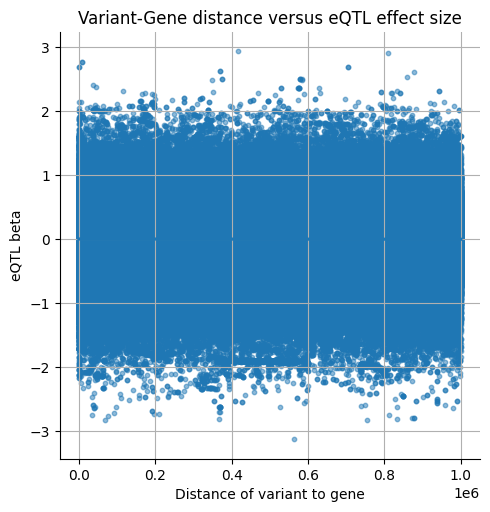

In [7]:
# plot the beta vs the distance
plt.figure(figsize=(10, 6))
sns.lmplot(data=eqtl_output_mono, x='distance', y='beta', ci=None, scatter_kws={'s': 10, 'alpha': 0.5})
plt.title('Variant-Gene distance versus eQTL effect size')
plt.xlabel('Distance of variant to gene')
plt.ylabel('eQTL beta')
plt.grid(True)
plt.show()

In [8]:
# add significance
eqtl_output_mono['significant'] = ((eqtl_output_mono['feature_q_value'] < 0.05) & (eqtl_output_mono['p_value'] < 0.05))

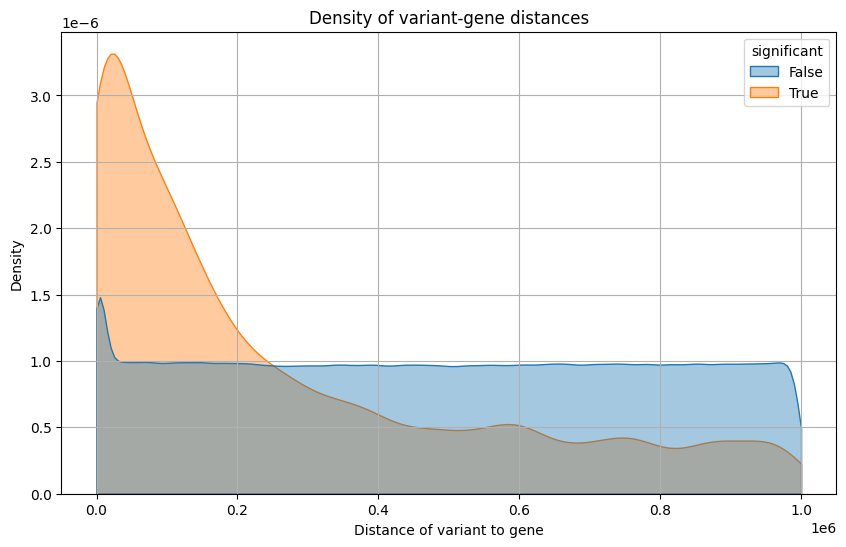

In [9]:
# plot the density of distances
plt.figure(figsize=(10, 6))
sns.kdeplot(data=eqtl_output_mono, x="distance", hue="significant", cut=0, fill=True, common_norm=False, alpha=0.4)
plt.title('Density of variant-gene distances')
plt.xlabel('Distance of variant to gene')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [10]:
# read the caQTL output
caqtl_output_mono = pd.read_csv(caqtl_output_mono_loc, usecols=usecols, sep = '\t')
# get the distances
caqtl_output_mono['distance'] = get_variant_feature_distances(caqtl_output_mono)

In [11]:
# add significance
caqtl_output_mono['significant'] = ((caqtl_output_mono['feature_q_value'] < 0.05) & (caqtl_output_mono['p_value'] < 0.05))

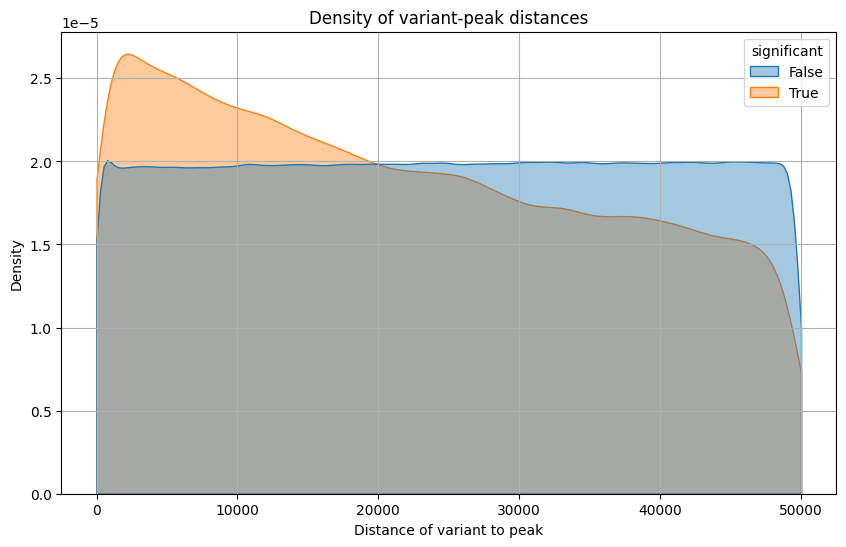

In [12]:
# plot the density of distances
plt.figure(figsize=(10, 6))
sns.kdeplot(data=caqtl_output_mono, x="distance", hue="significant", cut=0, fill=True, common_norm=False, alpha=0.4)
plt.title('Density of variant-peak distances')
plt.xlabel('Distance of variant to peak')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [13]:
# now let's check the top effects only
caqtl_output_mono_top_effects = caqtl_output_mono.sort_values(by = 'p_value')
caqtl_output_mono_top_effects = caqtl_output_mono_top_effects.drop_duplicates(subset=['feature_id'], keep='first')

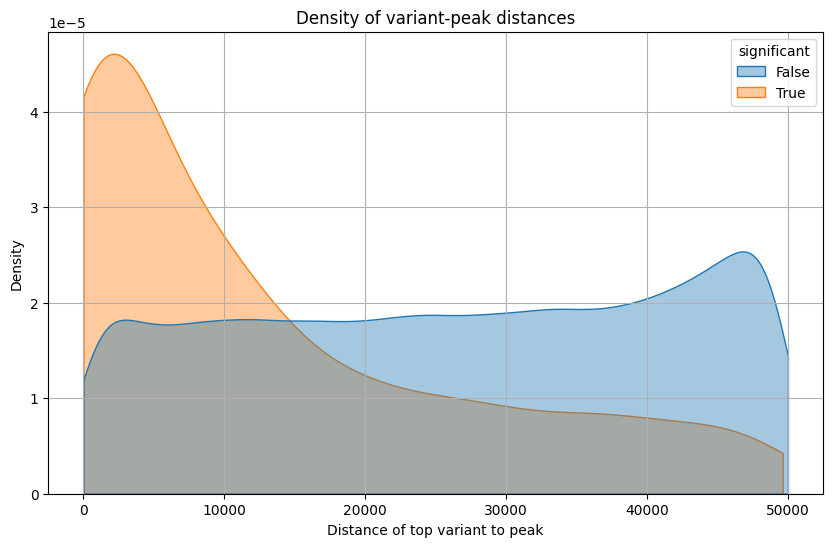

In [14]:
# plot the density of distances
plt.figure(figsize=(10, 6))
sns.kdeplot(data=caqtl_output_mono_top_effects, x="distance", hue="significant", cut=0, fill=True, common_norm=False, alpha=0.4)
plt.title('Density of variant-peak distances')
plt.xlabel('Distance of top variant to peak')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [15]:
# save as a file as well
caqtl_output_mono_top_effects.to_csv('/groups/umcg-franke-scrna/tmp04/projects/multiome/ongoing/qtl/mo_top_caqtls.tsv.gz', sep = '\t', index = False, header = True, compression = 'gzip')